<a href="https://colab.research.google.com/github/adarshpratap231043-arch/machine-learning/blob/main/ML(28_04_26)_Image_Classification_using_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial : Covid 19 Prediction using Artificial Neural Networks

Dataset: [Covid 19 Chest X-ray dataset](https://www.kaggle.com/tawsifurrahman/covid19-radiography-database)


A team of researchers from Qatar University, Doha, Qatar, and the University of Dhaka, Bangladesh along with their collaborators from Pakistan and Malaysia in collaboration with medical doctors have created a database of chest X-ray images for COVID-19 positive cases along with Normal and Viral Pneumonia images. This COVID-19, normal, and other lung infection dataset is released in stages. In the first release, we have released 219 COVID-19, 1341 normal, and 1345 viral pneumonia chest X-ray (CXR) images. In the first update, we have increased the COVID-19 class to 1200 CXR images. In the 2nd update, we have increased the database to 3616 COVID-19 positive cases along with 10,192 Normal, 6012 Lung Opacity (Non-COVID lung infection), and 1345 Viral Pneumonia images. We will continue to update this database as soon as we have new x-ray images for COVID-19 pneumonia patients.



**1. Mount the Google Drive**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**2. Move to the place where data resides**

In [4]:
%cd /content/drive/MyDrive/CSIT12025/

[Errno 2] No such file or directory: '/content/drive/MyDrive/CSIT12025/'
/content


In [5]:
!ls

covid_dataset.zip  drive  sample_data


**3. Unziping the dataset**

In [6]:
!pip install unzip

  Preparing metadata (setup.py) ... done
  Created wheel for unzip: filename=unzip-1.0.0-py3-none-any.whl size=1281 sha256=6a185163dbb70aacb3b3de063333faa81cd3e0b8fbbfdc9690d23e3b82f6dbb5
  Stored in directory: /root/.cache/pip/wheels/fb/5b/81/0f3e1e533b52883f88ab978178c15627a4fce4c13f74911dce
Successfully built unzip


In [9]:
!unzip covid_dataset.zip

Archive:  covid_dataset.zip
replace covid_dataset/COVID/COVID-1.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: covid_dataset/COVID/COVID-1.png  
replace covid_dataset/COVID/COVID-10.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: covid_dataset/COVID/COVID-10.png  
replace covid_dataset/COVID/COVID-11.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: covid_dataset/COVID/COVID-11.png  
replace covid_dataset/COVID/COVID-12.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: covid_dataset/COVID/COVID-12.png  
replace covid_dataset/COVID/COVID-13.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: covid_dataset/COVID/COVID-13.png  
replace covid_dataset/COVID/COVID-14.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: covid_dataset/COVID/COVID-14.png  
replace covid_dataset/COVID/COVID-15.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: covid_dataset/COVID/COVID-15.png  
replace covid_dataset/COVID/COVID-16.png? [y]es, [n]o, [A]ll, [N

**4. Install split folder python package**

https://pypi.org/project/split-folders/

In [11]:
!pip install split_folders

**5. Splitting the data in training, testing and validation set**

In [14]:
import splitfolders
splitfolders.ratio("covid_dataset", output="split", seed=1337, ratio=(.8, .1, .1), group_prefix=None)

Copying files: 150 files [00:00, 3296.56 files/s]


**6. Loading the dataset with normalization in batches**

In [36]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Normalize training and validation data in the range of 0 to 1
# Added data augmentation for training images to prevent overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Read the training sample and set the batch size
train_generator = train_datagen.flow_from_directory(
        'split/train/',
        target_size=(128, 128),
        batch_size=8,
        seed=100,
        class_mode='categorical')

# Read Validation data from directory and define target size with batch size
validation_generator = validation_datagen.flow_from_directory(
        'split/val/',
        target_size=(128, 128),
        batch_size=8,
        class_mode='categorical',
        seed=1000,
        shuffle=False)

test_generator = test_datagen.flow_from_directory(
        'split/test/',
        target_size=(128, 128),
        batch_size=8,
        seed=500,
        class_mode='categorical',
        shuffle=False)

Found 120 images belonging to 3 classes.
Found 15 images belonging to 3 classes.
Found 15 images belonging to 3 classes.


**7. Model Building**

In [37]:
from tensorflow import keras
from tensorflow.keras import layers

# Define a simple CNN model with Dropout layers for regularization
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # Added Dropout
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # Added Dropout
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # Added Dropout
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Added Dropout before final classification layer
    layers.Dense(3, activation='softmax') # 3 classes for COVID, Normal, Viral Pneumonia
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,699,139 (6.48 MB)

 Trainable params: 1,699,139 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

### Transfer Learning Model Building (VGG16)

In [38]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout

# Load the VGG16 model with pre-trained ImageNet weights, excluding the top (classification) layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the layers of the pre-trained model
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers on top of the VGG16 base
x = base_model.output
x = Flatten()(x) # Flatten the output from the convolutional base
x = Dense(256, activation='relu')(x) # Add a new dense layer
x = Dropout(0.5)(x) # Add dropout for regularization
predictions = Dense(3, activation='softmax')(x) # Final classification layer for 3 classes

# Create the new model
transfer_model = Model(inputs=base_model.input, outputs=predictions)

transfer_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,867 (64.14 MB)

 Trainable params: 2,098,179 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Transfer Learning Model Compilation and Training

In [39]:
from tensorflow.keras.optimizers import Adam

# Compile the transfer learning model
adam_tl = Adam(learning_rate=0.0001)
transfer_model.compile(optimizer=adam_tl, loss='categorical_crossentropy', metrics=['accuracy'])

# Train the transfer learning model
history_tl = transfer_model.fit(
    train_generator,
    steps_per_epoch=int(train_generator.samples / train_generator.batch_size),
    epochs=20, # Start with fewer epochs for transfer learning
    validation_data=validation_generator,
    validation_steps=int(validation_generator.samples / validation_generator.batch_size),
    verbose=1
)

# Unfreeze some layers of the base model and re-train with a lower learning rate
# This is a common fine-tuning step, but we'll keep it simple for now
# If performance is still not good, consider fine-tuning a few top layers of the VGG16 base.

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 182ms/step - accuracy: 0.3083 - loss: 1.3302 - val_accuracy: 0.8750 - val_loss: 0.7822
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.3833 - loss: 1.1221 - val_accuracy: 0.6250 - val_loss: 0.8936
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.4417 - loss: 1.0551 - val_accuracy: 0.3750 - val_loss: 0.9623
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.5917 - loss: 0.8825 - val_accuracy: 0.6250 - val_loss: 0.7367
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.6667 - loss: 0.7770 - val_accuracy: 0.3750 - val_loss: 0.8982
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.6500 - loss: 0.7903 - val_accuracy: 0.6250 - val_loss: 0.6870
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.7000 - loss: 0.6877 - val_accuracy: 0.5000 - val_loss: 0.8924
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.7083 - loss: 0.7220 - val_accuracy: 0.7500 - 

**8. Model Compilation and Training**

In [40]:
from tensorflow.keras.optimizers import Adam

adam = Adam(learning_rate=0.0001)
# We are going to use accuracy metrics and cross entropy loss as performance parameters
model.compile(adam, loss='categorical_crossentropy', metrics=['accuracy'])  # Use 'accuracy'
# Train the model
history = model.fit(train_generator,
      steps_per_epoch=int(train_generator.samples / train_generator.batch_size),  # Convert to int
      epochs=100,
      validation_data=validation_generator,
      validation_steps=int(validation_generator.samples / validation_generator.batch_size),  # Convert to int
      verbose=1)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.3417 - loss: 1.2015 - val_accuracy: 0.6250 - val_loss: 1.0617
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.3000 - loss: 1.1441 - val_accuracy: 0.5000 - val_loss: 1.0770
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.3917 - loss: 1.0662 - val_accuracy: 0.6250 - val_loss: 1.0869
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.4417 - loss: 1.0752 - val_accuracy: 0.2500 - val_loss: 1.1115
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.4083 - loss: 1.1042 - val_accuracy: 0.2500 - val_loss: 1.0915
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.3833 - loss: 1.0833 - val_accuracy: 0.5000 - val_loss: 1.0766
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.3917 - loss: 1.0805 - val_accuracy: 0.6250 - val_loss: 1.0872
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.3833 - loss: 1.0828 - val_accuracy: 0.

**9. Model saving**

In [18]:
model.save('covid_classification.h5')

**10. Model loading**

In [ ]:
from tensorflow.keras import models
model = models.load_model('covid_classification.h5')

**11. Model weights saving**

In [ ]:
model.save_weights('covid_classification_weights.weights.h5')

**12. Model weights loading**

In [ ]:
model.load_weights('covid_classification_weights.weights.h5')

**13. Plotting accuracy and loss graph for training and validation dataset**

In [ ]:
train_acc = history.history['accuracy'] # Change 'acc' to 'accuracy'
val_acc = history.history['val_accuracy'] # Change 'val_acc' to 'val_accuracy'
train_loss = history.history['loss']
val_loss = history.history['val_loss']

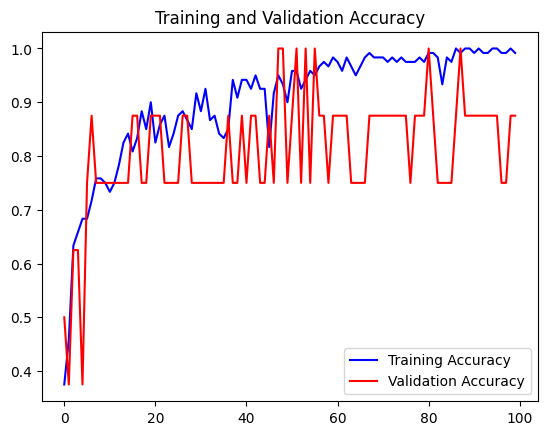

<Figure size 640x480 with 0 Axes>

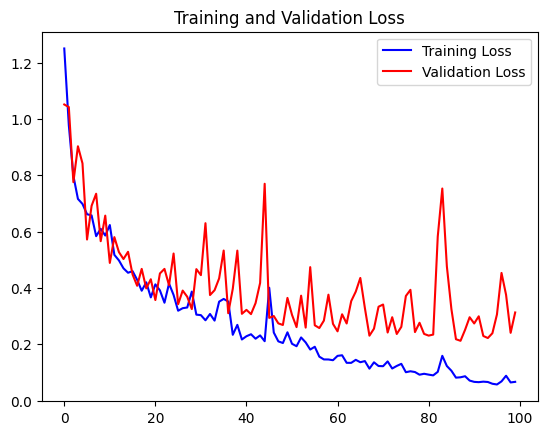

In [ ]:
import matplotlib.pyplot as plt
epochs = range(len(train_acc))
plt.plot(epochs, train_acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.figure()
plt.show()

plt.plot(epochs, train_loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


**14. Evaluate model performance on test dataset**

In [ ]:
test_output = model.evaluate(
    test_generator,
    steps=int(test_generator.samples / test_generator.batch_size),  # Convert steps to an integer
    verbose=1
)
print(test_output)
print(model.metrics_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 786ms/step - accuracy: 0.6250 - loss: 1.3278
[1.3277722597122192, 0.625]
['loss', 'compile_metrics']


References:

1. https://pypi.org/project/split-folders/
2. https://keras.io/